###Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import to_categorical

###Load MNIST Data

In [ ]:
# Load dataset from python data lab
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Check the shape
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

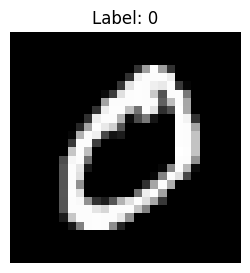

In [ ]:
# Visualize sample image
plt.figure(figsize=(3, 3))       #Dimension
plt.imshow(X_train[1], cmap='gray')
plt.title(f"Label: {np.argmax(y_train[1])}")
plt.axis('off')


###Preprocessing

In [ ]:
# Normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Do one-hot encoding on labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

###Build the Neural Network

In [ ]:
# Build NN
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')])

###Compile

In [ ]:
# Configure the model for training
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

###Train the Model

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs = 10,
                    batch_size = 32,
                    validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8672 - loss: 0.4648 - val_accuracy: 0.9525 - val_loss: 0.1664
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9615 - loss: 0.1332 - val_accuracy: 0.9662 - val_loss: 0.1154
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9754 - loss: 0.0843 - val_accuracy: 0.9687 - val_loss: 0.1025
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0636 - val_accuracy: 0.9740 - val_loss: 0.0883
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9870 - loss: 0.0444 - val_accuracy: 0.9724 - val_loss: 0.0958
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9899 - loss: 0.0337 - val_accuracy: 0.9751 - val_loss: 0.0890
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9908 - loss: 0.0294 - val_accuracy: 0.9746 - val_loss: 0.0948
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9926 - loss: 0.0227 - 

###**Evaluation**

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9681 - loss: 0.1200
Test Accuracy: 0.9721999764442444


###**Make Prediction**

In [ ]:
predictions = model.predict(X_test)

predicited_digit = np.argmax(predictions[1])
true_digit = np.argmax(y_test[1])

print("True Digit:", true_digit)
print("Predicted Digit:", predicited_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
True Digit: 2
Predicted Digit: 2


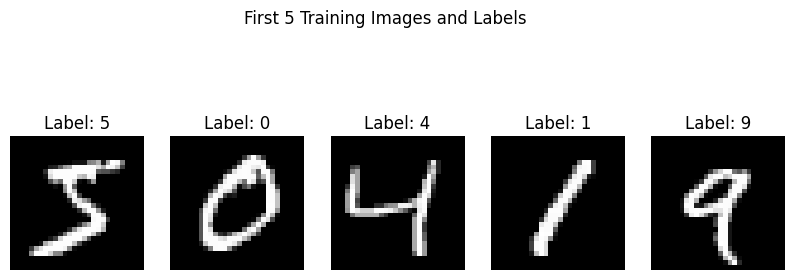

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Display the first 5 training images and their labels
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    # y_train is one-hot encoded, so we use np.argmax to get the digit
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('First 5 Training Images and Labels')
plt.show()

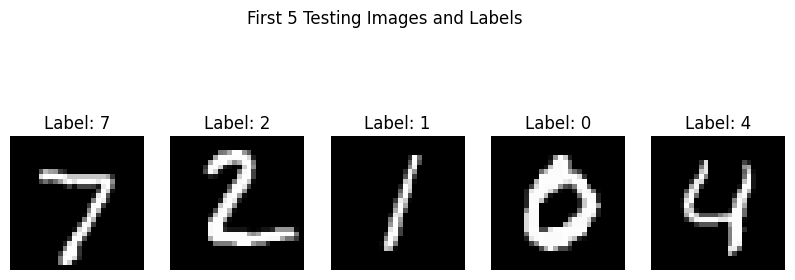

In [ ]:
# Display the first 5 testing images and their labels
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    # y_test is one-hot encoded, so we use np.argmax to get the digit
    plt.title(f"Label: {np.argmax(y_test[i])}")
    plt.axis('off')
plt.suptitle('First 5 Testing Images and Labels')
plt.show()

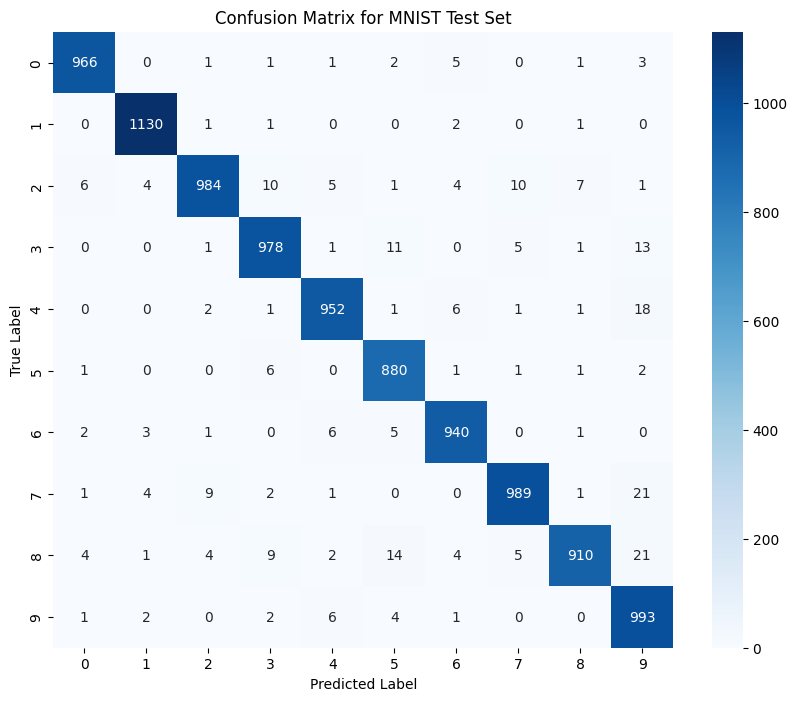

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels from y_test (which is one-hot encoded)
true_labels = np.argmax(y_test, axis=1)

# Get predicted labels from the model's predictions
predicted_labels = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST Test Set')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Ensure true_labels and predicted_labels are available
# (they should be from the confusion matrix step)
if 'true_labels' not in locals() or 'predicted_labels' not in locals():
    true_labels = np.argmax(y_test, axis=1)
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=[str(i) for i in range(10)])

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.95      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.99      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.98      0.93      0.96       974
           9       0.93      0.98      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

